<a href="https://colab.research.google.com/github/lakshlahoti15/MDS_LAB/blob/main/MDS_WEEK_9%2C10%2C11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd

# Load the datasets
application_df = pd.read_csv('/content/application_record.csv')
credit_df = pd.read_csv('/content/credit_record.csv')

print("Application Record DataFrame Info:")
application_df.info()
print("\nCredit Record DataFrame Info:")
credit_df.info()

Application Record DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-n

In [19]:
# Merge the two dataframes
merged_df = pd.merge(application_df, credit_agg, on='ID', how='inner')

# Drop duplicates based on 'ID' from the merged dataframe
merged_df.drop_duplicates(subset=['ID'], inplace=True)

# Convert DAYS_BIRTH to age in years (positive values)
merged_df['AGE_YEARS'] = -merged_df['DAYS_BIRTH'] // 365

# Convert DAYS_EMPLOYED to years and handle outliers
# Positive values in DAYS_EMPLOYED often indicate that the person is unemployed or that the data is erroneous.
# I'll replace these with 0 (representing 0 years of employment) and convert the rest to positive years.
merged_df['YEARS_EMPLOYED'] = -merged_df['DAYS_EMPLOYED'] // 365
merged_df.loc[merged_df['YEARS_EMPLOYED'] < 0, 'YEARS_EMPLOYED'] = 0

# Drop original 'DAYS_BIRTH' and 'DAYS_EMPLOYED' columns as new features are created
merged_df.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'], inplace=True)

print("Merged DataFrame Head after cleaning:")
display(merged_df.head())
print("Merged DataFrame Info after cleaning:")
merged_df.info()

Merged DataFrame Head after cleaning:


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,has_bad_status,AGE_YEARS,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,0,32,12
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,0,32,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,0,58,3
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,0,52,8
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,0,52,8


Merged DataFrame Info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  FLAG_MOBIL           36457 non-null  int64  
 11  FLAG_WORK_PHONE      36457 non-null  int64  
 12  FLAG_PHONE           36457 non-null  int64  
 13  FLAG_EMAIL           36457 non-null  int64  
 14  OCCUPATION_TYPE      25134 non-null  object 
 15

In [20]:
# Identify categorical columns for one-hot encoding
categorical_cols = merged_df.select_dtypes(include=['object']).columns

# Apply one-hot encoding
encoded_df = pd.get_dummies(merged_df, columns=categorical_cols, drop_first=True)

# Drop the original ID column as it's no longer needed for modeling
encoded_df.drop(columns=['ID'], inplace=True)

print("DataFrame Head after One-Hot Encoding:")
display(encoded_df.head())
print("\nDataFrame Info after One-Hot Encoding:")
encoded_df.info()

DataFrame Head after One-Hot Encoding:


,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,has_bad_status,AGE_YEARS,YEARS_EMPLOYED,...,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff
0,0,427500.0,1,1,0,0,2.0,0,32,12,...,False,False,False,False,False,False,False,False,False,False
1,0,427500.0,1,1,0,0,2.0,0,32,12,...,False,False,False,False,False,False,False,False,False,False
2,0,112500.0,1,0,0,0,2.0,0,58,3,...,False,False,False,False,False,False,False,False,True,False
3,0,270000.0,1,0,1,1,1.0,0,52,8,...,False,False,False,False,False,False,True,False,False,False
4,0,270000.0,1,0,1,1,1.0,0,52,8,...,False,False,False,False,False,False,True,False,False,False



DataFrame Info after One-Hot Encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 47 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   CNT_CHILDREN                                       36457 non-null  int64  
 1   AMT_INCOME_TOTAL                                   36457 non-null  float64
 2   FLAG_MOBIL                                         36457 non-null  int64  
 3   FLAG_WORK_PHONE                                    36457 non-null  int64  
 4   FLAG_PHONE                                         36457 non-null  int64  
 5   FLAG_EMAIL                                         36457 non-null  int64  
 6   CNT_FAM_MEMBERS                                    36457 non-null  float64
 7   has_bad_status                                     36457 non-null  int64  
 8   AGE_YEARS                                     

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good choice for small datasets and binary classification
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     10753
           1       0.00      0.00      0.00       185

    accuracy                           0.98     10938
   macro avg       0.49      0.50      0.50     10938
weighted avg       0.97      0.98      0.97     10938


Confusion Matrix:
[[10753     0]
 [  185     0]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Original training set shape: {X_train.shape}")
print(f"Original training target distribution: {Counter(y_train)}")

# Apply SMOTE to the training data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Resampled training set shape: {X_train_res.shape}")
print(f"Resampled training target distribution: {Counter(y_train_res)}")

# Retrain the Logistic Regression model on the resampled data
model_resampled = LogisticRegression(random_state=42, solver='liblinear')
model_resampled.fit(X_train_res, y_train_res)

# Make predictions on the original test set
y_pred_resampled = model_resampled.predict(X_test)

# Evaluate the model with resampled training data
print("\nClassification Report after SMOTE:")
print(classification_report(y_test, y_pred_resampled))

print("\nConfusion Matrix after SMOTE:")
print(confusion_matrix(y_test, y_pred_resampled))

Original training set shape: (25519, 47)
Original training target distribution: Counter({0: 25088, 1: 431})
Resampled training set shape: (50176, 47)
Resampled training target distribution: Counter({0: 25088, 1: 25088})

Classification Report after SMOTE:
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     10753
           1       0.02      0.19      0.03       185

    accuracy                           0.82     10938
   macro avg       0.50      0.51      0.47     10938
weighted avg       0.97      0.82      0.88     10938


Confusion Matrix after SMOTE:
[[8891 1862]
 [ 150   35]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


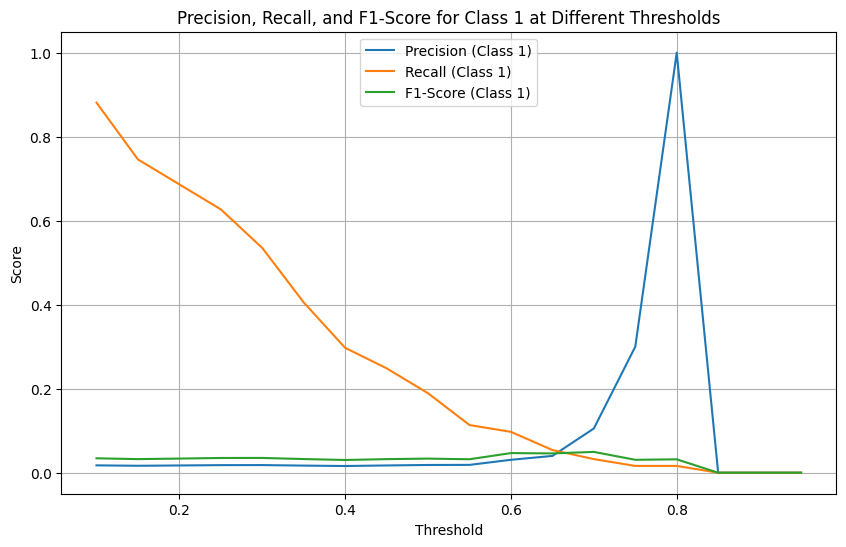

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

# Get probabilities for the positive class (class 1)
y_pred_proba = model_resampled.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 1.0, 0.05) # Test thresholds from 0.1 to 0.95
precision_scores = []
recall_scores = []
f1_scores = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_threshold, average='binary', pos_label=1)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision_scores, label='Precision (Class 1)')
plt.plot(thresholds, recall_scores, label='Recall (Class 1)')
plt.plot(thresholds, f1_scores, label='F1-Score (Class 1)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-Score for Class 1 at Different Thresholds')
plt.legend()
plt.grid(True)
plt.show()

The plot above shows the trade-off between Precision, Recall, and F1-Score for class 1 (bad status) at various classification thresholds.

*   **Precision** measures how many of the positive predictions were actually correct (minimizes false positives).
*   **Recall** measures how many of the actual positive cases were correctly identified (minimizes false negatives).
*   **F1-Score** is the harmonic mean of precision and recall, providing a single metric that balances both.

Now, based on this visualization, you can choose a threshold that best suits your business needs. For example:

*   If minimizing false positives (wrongly flagging a good customer as bad) is crucial, you might choose a higher threshold, accepting lower recall.
*   If minimizing false negatives (missing actual bad customers) is crucial, you might choose a lower threshold, accepting lower precision.

What threshold would you like to set for the model, or would you like me to suggest one based on maximizing F1-score for class 1?

In [24]:
# Identify the optimal threshold maximizing F1-score for class 1
max_f1_score_class1 = max(f1_scores)
optimal_threshold_index = f1_scores.index(max_f1_score_class1)
optimal_threshold = thresholds[optimal_threshold_index]

print(f"Optimal threshold selected based on max F1-score for class 1: {optimal_threshold:.2f}")

# Make predictions using the optimal threshold
y_pred_optimal_threshold = (y_pred_proba >= optimal_threshold).astype(int)

# Convert 'has_bad_status' predictions to 'eligibility' predictions
# has_bad_status = 1 means NOT eligible (0)
# has_bad_status = 0 means ELIGIBLE (1)
eligibility_predictions = 1 - y_pred_optimal_threshold

print("\nSample Eligibility Predictions (1 = Eligible, 0 = Not Eligible):")
for i in range(10):
    print(f"Customer ID (test set index): {X_test.index[i]}, Predicted Eligibility: {eligibility_predictions[i]}")

# Display classification report for eligibility predictions (inverted target)
# Note: When inverting, the 'positive' class (1) for eligibility corresponds to original 'has_bad_status' == 0
# And 'negative' class (0) for eligibility corresponds to original 'has_bad_status' == 1
# We'll adjust the target and predictions for the report to reflect eligibility

y_test_eligibility = 1 - y_test

print("\nClassification Report for Eligibility Predictions:")
print(classification_report(y_test_eligibility, eligibility_predictions))

Optimal threshold selected based on max F1-score for class 1: 0.70

Sample Eligibility Predictions (1 = Eligible, 0 = Not Eligible):
Customer ID (test set index): 34639, Predicted Eligibility: 1
Customer ID (test set index): 3995, Predicted Eligibility: 1
Customer ID (test set index): 3686, Predicted Eligibility: 1
Customer ID (test set index): 30250, Predicted Eligibility: 1
Customer ID (test set index): 17386, Predicted Eligibility: 1
Customer ID (test set index): 679, Predicted Eligibility: 1
Customer ID (test set index): 17612, Predicted Eligibility: 1
Customer ID (test set index): 35243, Predicted Eligibility: 1
Customer ID (test set index): 2280, Predicted Eligibility: 1
Customer ID (test set index): 15704, Predicted Eligibility: 1

Classification Report for Eligibility Predictions:
              precision    recall  f1-score   support

           0       0.11      0.03      0.05       185
           1       0.98      1.00      0.99     10753

    accuracy                        

In [25]:
def predict_eligibility_from_user_input(model, scaler, optimal_threshold, X_columns, merged_df_for_categories):
    """
    Collects user input, preprocesses it, and predicts credit card eligibility.
    """
    user_data = {}

    print("\nPlease answer the following questions to determine your credit card eligibility:")

    # Numerical features that were scaled
    numerical_features_to_scale = ['AMT_INCOME_TOTAL', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'AGE_YEARS', 'YEARS_EMPLOYED']

    # Collect numerical inputs, reordered for conditional logic
    user_data['AGE_YEARS'] = int(input("Your age in years: "))

    # Conditional question for children
    if user_data['AGE_YEARS'] <= 18:
        user_data['CNT_CHILDREN'] = 0
        print("Number of children: 0 (Automatically set as age is 18 or less).")
    else:
        user_data['CNT_CHILDREN'] = int(input("Number of children: "))

    user_data['YEARS_EMPLOYED'] = int(input("Years employed (enter 0 if unemployed): "))
    user_data['AMT_INCOME_TOTAL'] = float(input("Total annual income: "))
    user_data['CNT_FAM_MEMBERS'] = float(input("Number of family members: "))

    # Binary flag features
    user_data['FLAG_MOBIL'] = int(input("Do you own a mobile phone? (1 for Yes, 0 for No): "))
    user_data['FLAG_WORK_PHONE'] = int(input("Do you have a work phone? (1 for Yes, 0 for No): "))
    user_data['FLAG_PHONE'] = int(input("Do you have a home phone? (1 for Yes, 0 for No): "))
    user_data['FLAG_EMAIL'] = int(input("Do you have an email? (1 for Yes, 0 for No): "))

    # Categorical features that were one-hot encoded
    user_data['CODE_GENDER'] = input("Your gender (M/F): ").upper()
    user_data['FLAG_OWN_CAR'] = input("Do you own a car? (Y/N): ").upper()
    user_data['FLAG_OWN_REALTY'] = input("Do you own real estate? (Y/N): ").upper()

    # Get unique values for other categorical features from the original merged_df
    income_types = merged_df_for_categories['NAME_INCOME_TYPE'].unique()
    education_types = merged_df_for_categories['NAME_EDUCATION_TYPE'].unique()
    family_status_types = merged_df_for_categories['NAME_FAMILY_STATUS'].unique()
    housing_types = merged_df_for_categories['NAME_HOUSING_TYPE'].unique()
    occupation_types = merged_df_for_categories['OCCUPATION_TYPE'].unique()

    user_data['NAME_INCOME_TYPE'] = input(f"Income type {list(income_types)}: ")
    user_data['NAME_EDUCATION_TYPE'] = input(f"Education type {list(education_types)}: ")
    user_data['NAME_FAMILY_STATUS'] = input(f"Family status {list(family_status_types)}: ")
    user_data['NAME_HOUSING_TYPE'] = input(f"Housing type {list(housing_types)}: ")

    # Conditional question for occupation type
    if user_data['YEARS_EMPLOYED'] == 0:
        user_data['OCCUPATION_TYPE'] = 'Unknown' # Consistent with how NaN occupation was handled
        print(f"Occupation type: '{user_data['OCCUPATION_TYPE']}' (Automatically set as years employed is 0).")
    else:
        user_data['OCCUPATION_TYPE'] = input(f"Occupation type {list(occupation_types)}: ")

    # Convert user_data to DataFrame for preprocessing
    user_df = pd.DataFrame([user_data])

    # Apply one-hot encoding as done for the training data
    # First, make sure all categorical columns that were in merged_df are present
    # before get_dummies to ensure correct columns are created even if user's input doesn't cover all
    categorical_cols_original = merged_df_for_categories.select_dtypes(include=['object']).columns
    for col in categorical_cols_original:
      if col not in user_df.columns: # for those where user didn't input directly due to drop_first=True mapping
        user_df[col] = '' # Placeholder, will be handled by get_dummies

    # Set all categorical columns from user_df to 'category' dtype to ensure get_dummies handles them consistently
    for col in categorical_cols_original:
        user_df[col] = pd.Categorical(user_df[col], categories=merged_df_for_categories[col].unique())

    user_encoded_df = pd.get_dummies(user_df, columns=categorical_cols_original, drop_first=True)

    # Align columns with training data (X_columns) - crucial step
    # Create a DataFrame with all X_columns, initialized to 0, then fill in user values
    final_user_features = pd.DataFrame(0, index=[0], columns=X_columns)
    for col in final_user_features.columns:
        if col in user_encoded_df.columns:
            final_user_features[col] = user_encoded_df[col]

    # Scale numerical features
    final_user_features[numerical_features_to_scale] = scaler.transform(final_user_features[numerical_features_to_scale])

    # Make prediction
    prediction_proba = model.predict_proba(final_user_features)[:, 1]

    # Apply optimal threshold and convert to eligibility
    has_bad_status_pred = (prediction_proba >= optimal_threshold).astype(int)
    eligibility = 1 - has_bad_status_pred[0] # [0] because it's a single prediction

    if eligibility == 1:
        print("\nCongratulations! You are eligible for a credit card.")
    else:
        print("\nWe regret to inform you that you are currently not eligible for a credit card.")

    print(f"(Probability of bad status: {prediction_proba[0]:.4f})")



To use the interactive prediction tool, simply run the cell above defining the `predict_eligibility_from_user_input` function, and then run the following cell to call the function.

In [26]:
# Call the function for interactive prediction
predict_eligibility_from_user_input(model_resampled, scaler, optimal_threshold, X_train.columns, merged_df)


Please answer the following questions to determine your credit card eligibility:


KeyboardInterrupt: Interrupted by user

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
X = encoded_df.drop('has_bad_status', axis=1)
y = encoded_df['has_bad_status']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Identify numerical columns for scaling
numerical_cols = merged_df.select_dtypes(include=['int64', 'float64']).columns.drop(['ID', 'CNT_FAM_MEMBERS', 'has_bad_status', 'CNT_CHILDREN'])
# Note: CNT_CHILDREN and CNT_FAM_MEMBERS are counts, but AGE_YEARS and YEARS_EMPLOYED are continuous-like values that benefit from scaling.
# FLAG_MOBIL, FLAG_WORK_PHONE, FLAG_PHONE, FLAG_EMAIL are already binary (0/1) so no need to scale.

# Exclude binary columns and other non-numerical ones from the numerical_cols for scaler
# Re-evaluating numerical columns after one-hot encoding and drops:
# X_train.select_dtypes(include=['int64', 'float64']).columns should give us the correct numerical columns after encoding.
# Let's ensure 'AMT_INCOME_TOTAL', 'AGE_YEARS', 'YEARS_EMPLOYED' are scaled.

numerical_features_to_scale = ['AMT_INCOME_TOTAL', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'AGE_YEARS', 'YEARS_EMPLOYED']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train[numerical_features_to_scale] = scaler.fit_transform(X_train[numerical_features_to_scale])
X_test[numerical_features_to_scale] = scaler.transform(X_test[numerical_features_to_scale])

print("X_train head after scaling:")
display(X_train.head())
print("\nX_test head after scaling:")
display(X_test.head())
print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

X_train head after scaling:


,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE_YEARS,YEARS_EMPLOYED,CODE_GENDER_M,...,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff
1315,-0.578262,-0.286034,1,1,0,0,-0.217363,-0.625227,1.467410,False,...,False,False,False,False,False,False,False,False,False,False
22248,-0.578262,1.036988,1,0,0,0,-1.310347,-0.191443,-0.874080,False,...,False,False,False,False,False,False,False,False,False,False
9791,2.108922,-0.947544,1,1,0,0,1.968604,-1.319281,0.062516,False,...,False,False,False,False,False,False,False,False,False,False
10178,2.108922,4.785548,1,0,1,0,1.968604,-0.451714,1.935708,True,...,False,False,False,False,False,False,False,False,False,False
28564,0.765330,-0.947544,1,0,0,0,0.875620,-1.406038,-0.561882,False,...,False,False,False,False,False,False,False,False,False,False



X_test head after scaling:


,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE_YEARS,YEARS_EMPLOYED,CODE_GENDER_M,...,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff
34639,2.108922,-0.065530,1,0,1,0,1.968604,-0.972254,-0.249683,True,...,False,False,False,False,False,False,False,False,False,False
3995,-0.578262,-0.727041,1,0,1,0,-0.217363,0.502610,0.218615,False,...,False,False,False,False,False,False,True,False,False,False
3686,3.452513,-0.286034,1,0,0,0,3.061588,-0.364957,0.686913,True,...,True,False,False,False,False,False,False,False,False,False
30250,-0.578262,1.036988,1,0,0,0,-0.217363,0.502610,-0.717981,True,...,False,False,True,False,False,False,False,False,False,False
17386,2.108922,2.580512,1,0,0,1,1.968604,-0.191443,2.091807,True,...,False,False,False,False,False,False,False,False,False,False



Shape of X_train: (25519, 46)
Shape of X_test: (10938, 46)
Shape of y_train: (25519,)
Shape of y_test: (10938,)


In [28]:
print("Application Record DataFrame Head:")
display(application_df.head())

print("\nCredit Record DataFrame Head:")
display(credit_df.head())

Application Record DataFrame Head:


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0



Credit Record DataFrame Head:


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [30]:
# Handle missing values in OCCUPATION_TYPE
application_df['OCCUPATION_TYPE'].fillna('Unknown', inplace=True)

# Define target variable in credit_df
# '0', '1', 'C', 'X' are considered good/neutral status
# '2', '3', '4', '5' are considered bad status
credit_df['has_bad_status'] = credit_df['STATUS'].apply(lambda x: 1 if x in ['2', '3', '4', '5'] else 0)

# Aggregate credit_df by ID: get the maximum 'has_bad_status' for each ID
# If a customer ever had a bad status, their aggregated 'has_bad_status' will be 1
credit_agg = credit_df.groupby('ID')['has_bad_status'].max().reset_index()

print("Application DataFrame after filling OCCUPATION_TYPE NaNs:")
application_df.info()
print("\nAggregated Credit DataFrame Head:")
display(credit_agg.head())
print("Aggregated Credit DataFrame Info:")
credit_agg.info()

Application DataFrame after filling OCCUPATION_TYPE NaNs:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE

,ID,has_bad_status
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


Aggregated Credit DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45985 entries, 0 to 45984
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ID              45985 non-null  int64
 1   has_bad_status  45985 non-null  int64
dtypes: int64(2)
memory usage: 718.6 KB
